# Demo BTL 2 - DL4CV - Nhóm group6

## Chuẩn bị môi trường

In [1]:
!pip install gradio torch torchvision numpy ultralytics -q

## Video inference

Trả về FPS và trung bình Conf qua thời gian

In [2]:
import cv2
import time
import torch
import numpy as np
import torchvision
from ultralytics import YOLO
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor

# --- KHỞI TẠO ---
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"[INFO] Hardware: {device}")

VOC_CLASSES = ['aeroplane', 'bicycle', 'bird', 'boat', 'bottle', 'bus', 'car', 'cat',
               'chair', 'cow', 'diningtable', 'dog', 'horse', 'motorbike', 'person',
               'pottedplant', 'sheep', 'sofa', 'train', 'tvmonitor']

# Load Models (Chỉ load 1 lần)
yolo_model = YOLO('best.pt')
yolo_model.to(device)

def get_faster_rcnn_model(num_classes):
    model = torchvision.models.detection.fasterrcnn_resnet50_fpn(weights=None)
    in_features = model.roi_heads.box_predictor.cls_score.in_features
    model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)
    return model

frcnn_model = get_faster_rcnn_model(len(VOC_CLASSES) + 1).to(device)
frcnn_model.load_state_dict(torch.load('faster_rcnn_voc_epoch_20.pt', map_location=device))
frcnn_model.eval()

def run_inference_engine(frame, model_type, conf_thresh):
    """Hàm lõi, ngắt timer chuẩn xác để đo latency thuần"""
    avg_conf = 0.0

    if model_type == "YOLOv8 Nano":
        start_time = time.perf_counter()
        results = yolo_model.predict(frame, conf=conf_thresh, verbose=False)
        if device.type == 'cuda': torch.cuda.synchronize()
        latency = time.perf_counter() - start_time

        confs = results[0].boxes.conf.cpu().numpy()
        if len(confs) > 0: avg_conf = confs.mean()

        # Lấy frame đã vẽ (cho Gradio Demo)
        res_frame = results[0].plot()

    elif model_type == "Faster R-CNN":
        frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        img_tensor = torch.from_numpy(frame_rgb).permute(2, 0, 1).float() / 255.0
        img_tensor = img_tensor.unsqueeze(0).to(device)

        start_time = time.perf_counter()
        with torch.no_grad():
            preds = frcnn_model(img_tensor)[0]
        if device.type == 'cuda': torch.cuda.synchronize()
        latency = time.perf_counter() - start_time

        scores = preds['scores'].cpu().numpy()
        valid_idx = scores >= conf_thresh
        valid_scores = scores[valid_idx]
        if len(valid_scores) > 0: avg_conf = valid_scores.mean()

        # Code vẽ box thủ công cho Faster R-CNN (giản lược để tập trung logic)
        res_frame = frame.copy()
        boxes = preds['boxes'].cpu().numpy()[valid_idx]
        labels = preds['labels'].cpu().numpy()[valid_idx]
        for box, label, score in zip(boxes, labels, valid_scores):
            x1, y1, x2, y2 = map(int, box)
            class_id = label - 1
            if 0 <= class_id < len(VOC_CLASSES):
                cv2.rectangle(res_frame, (x1, y1), (x2, y2), (0, 255, 0), 2)
                cv2.putText(res_frame, f"{VOC_CLASSES[class_id]} {score:.2f}", (x1, y1-10),
                            cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 2)

    return latency, avg_conf, res_frame

def process_video_metrics(video_path, model_type, conf_thresh):
    """Xử lý video và lưu lại timeline dữ liệu"""
    cap = cv2.VideoCapture(video_path)
    metrics = {"latencies": [], "fps": [], "confidences": []}

    # Warmup
    ret, frame = cap.read()
    if ret: run_inference_engine(frame, model_type, conf_thresh)

    while cap.isOpened():
        ret, frame = cap.read()
        if not ret: break

        latency, avg_conf, _ = run_inference_engine(frame, model_type, conf_thresh)

        metrics["latencies"].append(latency * 1000) # ms
        metrics["fps"].append(1.0 / latency if latency > 0 else 0)
        metrics["confidences"].append(avg_conf)

    cap.release()
    return metrics

[INFO] Hardware: cuda


Đang chạy profiling cho YOLOv8 Nano...


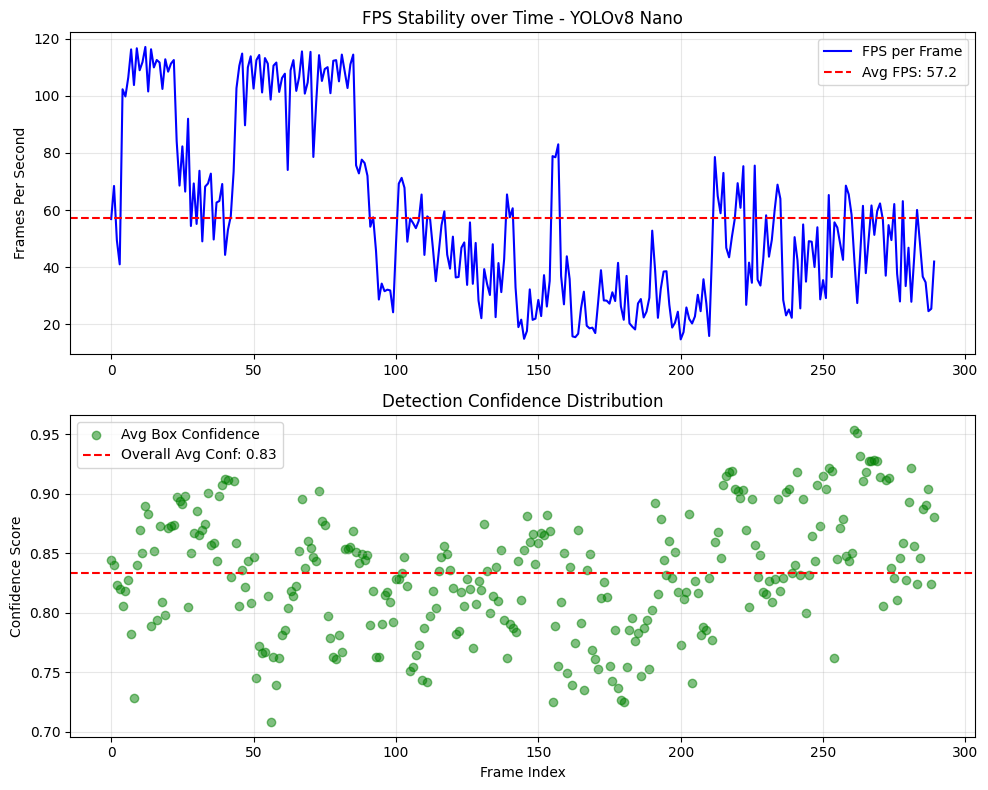

In [3]:
import matplotlib.pyplot as plt

# --- CẤU HÌNH ĐẦU VÀO ---
TEST_VIDEO = "video1.mp4"
MODEL_CHOICE = "YOLOv8 Nano" # Hoặc "Faster R-CNN"
CONF_THRESH = 0.5

# Thu thập dữ liệu
print(f"Đang chạy profiling cho {MODEL_CHOICE}...")
metrics_data = process_video_metrics(TEST_VIDEO, MODEL_CHOICE, CONF_THRESH)

# Trực quan hóa
frames = range(len(metrics_data["fps"]))

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8))

# Biểu đồ FPS
ax1.plot(frames, metrics_data["fps"], color='blue', label='FPS per Frame')
ax1.axhline(y=np.mean(metrics_data["fps"]), color='r', linestyle='--', label=f'Avg FPS: {np.mean(metrics_data["fps"]):.1f}')
ax1.set_title(f"FPS Stability over Time - {MODEL_CHOICE}")
ax1.set_ylabel("Frames Per Second")
ax1.legend()
ax1.grid(True, alpha=0.3)

# Biểu đồ Confidence
# Chỉ vẽ những frame có object (conf > 0)
valid_conf_idx = [i for i, c in enumerate(metrics_data["confidences"]) if c > 0]
valid_confs = [metrics_data["confidences"][i] for i in valid_conf_idx]

ax2.scatter(valid_conf_idx, valid_confs, color='green', alpha=0.5, label='Avg Box Confidence')
if valid_confs:
    ax2.axhline(y=np.mean(valid_confs), color='r', linestyle='--', label=f'Overall Avg Conf: {np.mean(valid_confs):.2f}')
ax2.set_title("Detection Confidence Distribution")
ax2.set_xlabel("Frame Index")
ax2.set_ylabel("Confidence Score")
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('yolo-hist-overtime.png', dpi=120, bbox_inches='tight')
plt.show()

Đang chạy profiling cho Faster R-CNN...


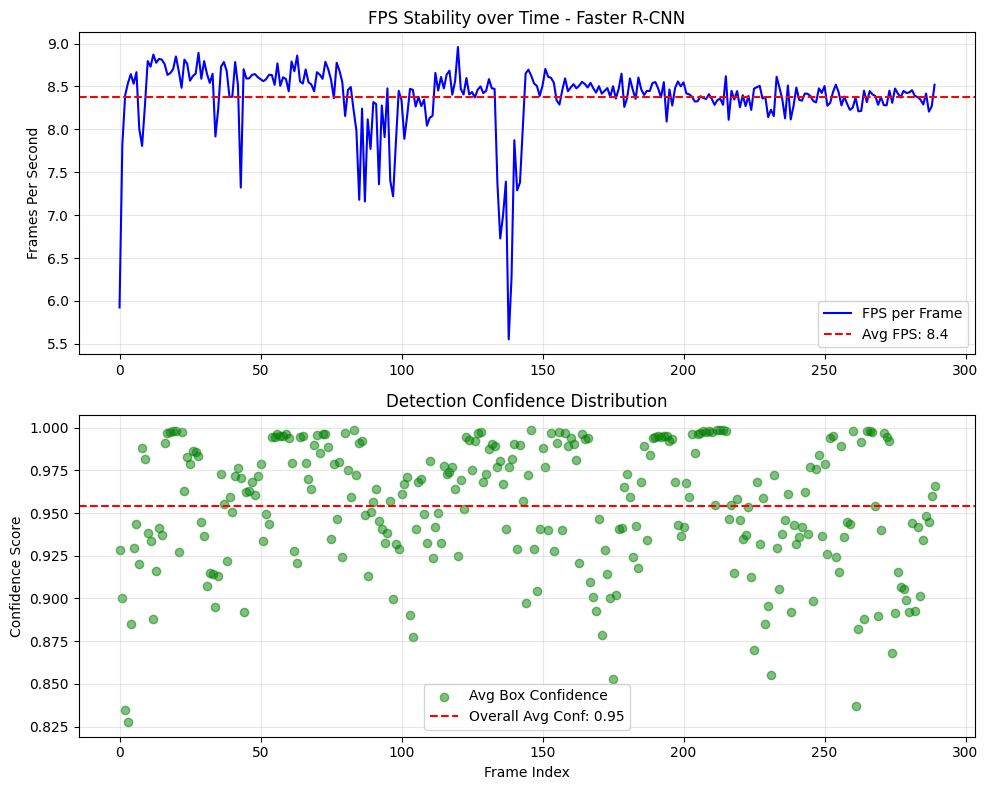

In [4]:
import matplotlib.pyplot as plt

# --- CẤU HÌNH ĐẦU VÀO ---
TEST_VIDEO = "video1.mp4"
MODEL_CHOICE = "Faster R-CNN" # Hoặc "Faster R-CNN"
CONF_THRESH = 0.5

# Thu thập dữ liệu
print(f"Đang chạy profiling cho {MODEL_CHOICE}...")
metrics_data = process_video_metrics(TEST_VIDEO, MODEL_CHOICE, CONF_THRESH)

# Trực quan hóa
frames = range(len(metrics_data["fps"]))

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8))

# Biểu đồ FPS
ax1.plot(frames, metrics_data["fps"], color='blue', label='FPS per Frame')
ax1.axhline(y=np.mean(metrics_data["fps"]), color='r', linestyle='--', label=f'Avg FPS: {np.mean(metrics_data["fps"]):.1f}')
ax1.set_title(f"FPS Stability over Time - {MODEL_CHOICE}")
ax1.set_ylabel("Frames Per Second")
ax1.legend()
ax1.grid(True, alpha=0.3)

# Biểu đồ Confidence
# Chỉ vẽ những frame có object (conf > 0)
valid_conf_idx = [i for i, c in enumerate(metrics_data["confidences"]) if c > 0]
valid_confs = [metrics_data["confidences"][i] for i in valid_conf_idx]

ax2.scatter(valid_conf_idx, valid_confs, color='green', alpha=0.5, label='Avg Box Confidence')
if valid_confs:
    ax2.axhline(y=np.mean(valid_confs), color='r', linestyle='--', label=f'Overall Avg Conf: {np.mean(valid_confs):.2f}')
ax2.set_title("Detection Confidence Distribution")
ax2.set_xlabel("Frame Index")
ax2.set_ylabel("Confidence Score")
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('ftrcnn-hist-overtime.png', dpi=120, bbox_inches='tight')
plt.show()

## Demo Gradio

In [ ]:
import gradio as gr
import cv2
import time
import torch
import numpy as np
from ultralytics import YOLO
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
import torchvision

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

VOC_CLASSES = ['aeroplane','bicycle','bird','boat','bottle','bus','car','cat',
               'chair','cow','diningtable','dog','horse','motorbike','person',
               'pottedplant','sheep','sofa','train','tvmonitor']

# Load YOLOv8
yolo_model = YOLO('best.pt')
print("Đã load YOLOv8")

# Load Faster R-CNN
def get_faster_rcnn_model(num_classes):
    model = torchvision.models.detection.fasterrcnn_resnet50_fpn(pretrained=False)
    in_features = model.roi_heads.box_predictor.cls_score.in_features
    model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)
    return model

frcnn_model = get_faster_rcnn_model(len(VOC_CLASSES) + 1).to(device)
frcnn_model.load_state_dict(torch.load('faster_rcnn_voc_epoch_20.pt', map_location=device))
frcnn_model.eval()
print("Đã load Faster R-CNN")

def draw_frcnn_boxes(image_np, boxes, labels, scores, conf_thresh):
    img_draw = image_np.copy()
    for box, label, score in zip(boxes, labels, scores):
        if score >= conf_thresh:
            x1, y1, x2, y2 = map(int, box)
            class_id = label.item() - 1 # Bỏ qua background
            if class_id < 0 or class_id >= len(VOC_CLASSES): continue

            name = VOC_CLASSES[class_id]
            text = f"{name} {score:.2f}"

            cv2.rectangle(img_draw, (x1, y1), (x2, y2), (0, 255, 0), 2)
            cv2.putText(img_draw, text, (x1, y1-10), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 2)
    return img_draw

def process_image(img, model_type, conf_thresh):
    if img is None: return None, "Chưa upload ảnh."

    start_time = time.time()

    if model_type == "YOLOv8 Nano":
        results = yolo_model.predict(img, conf=conf_thresh, verbose=False)
        res_img = results[0].plot()
    else: # Faster R-CNN
        img_tensor = torch.from_numpy(img).permute(2, 0, 1).float() / 255.0
        img_tensor = img_tensor.unsqueeze(0).to(device)

        with torch.no_grad():
            preds = frcnn_model(img_tensor)[0]

        res_img = draw_frcnn_boxes(img, preds['boxes'], preds['labels'], preds['scores'], conf_thresh)

    latency = time.time() - start_time
    fps = 1.0 / latency if latency > 0 else 0
    stats = f"⏱️ Thời gian Inference: {latency*1000:.1f} ms\n🚀 Tốc độ: {fps:.1f} FPS"

    return res_img, stats

def process_video(video_path, model_type, conf_thresh):
    if not video_path: return None, "Chưa upload video."

    cap = cv2.VideoCapture(video_path)
    width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    fps_video = cap.get(cv2.CAP_PROP_FPS)

    output_path = "output_demo.mp4"
    fourcc = cv2.VideoWriter_fourcc(*'mp4v')
    out = cv2.VideoWriter(output_path, fourcc, fps_video, (width, height))

    frame_count = 0
    total_latency = 0

    while cap.isOpened():
        ret, frame = cap.read()
        if not ret: break

        frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        start_time = time.time()

        if model_type == "YOLOv8 Nano":
            results = yolo_model.predict(frame_rgb, conf=conf_thresh, verbose=False)
            res_frame = results[0].plot()
        else:
            img_tensor = torch.from_numpy(frame_rgb).permute(2, 0, 1).float() / 255.0
            img_tensor = img_tensor.unsqueeze(0).to(device)
            with torch.no_grad():
                preds = frcnn_model(img_tensor)[0]
            res_frame = draw_frcnn_boxes(frame_rgb, preds['boxes'], preds['labels'], preds['scores'], conf_thresh)

        latency = time.time() - start_time
        total_latency += latency
        frame_count += 1

        # Ghi FPS lên frame
        current_fps = 1.0 / latency if latency > 0 else 0
        res_frame = cv2.cvtColor(res_frame, cv2.COLOR_RGB2BGR) # Đổi lại BGR để lưu video
        cv2.putText(res_frame, f"{model_type} - FPS: {current_fps:.1f}", (20, 50),
                    cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 0, 255), 2, cv2.LINE_AA)

        out.write(res_frame)

    cap.release()
    out.release()

    avg_fps = frame_count / total_latency if total_latency > 0 else 0
    stats = f"📹 Đã xử lý: {frame_count} frames\n⏱️ FPS Trung bình: {avg_fps:.1f} FPS"

    return output_path, stats

# --- 3. XÂY DỰNG GIAO DIỆN GRADIO ---
with gr.Blocks(theme=gr.themes.Soft()) as app:
    gr.Markdown("# BTL2: Nhận diện đối tượng (YOLOv8 vs Faster R-CNN)")
    gr.Markdown("Giao diện thực nghiệm đánh giá hiệu năng mô hình trên tập dữ liệu Pascal VOC 2012.")

    with gr.Tabs():
        # TAB 1: ẢNH
        with gr.TabItem("Suy luận trên Ảnh"):
            with gr.Row():
                with gr.Column():
                    img_input = gr.Image(label="Upload Ảnh")
                    model_opt_img = gr.Radio(["YOLOv8 Nano", "Faster R-CNN"], label="Chọn Mô hình", value="YOLOv8 Nano")
                    conf_slider_img = gr.Slider(0.1, 1.0, value=0.5, label="Confidence Threshold")
                    btn_img = gr.Button("Chạy Mô hình 🚀", variant="primary")
                with gr.Column():
                    img_output = gr.Image(label="Kết quả")
                    stats_img = gr.Textbox(label="Thông số Hiệu năng", lines=2)

            btn_img.click(process_image, inputs=[img_input, model_opt_img, conf_slider_img], outputs=[img_output, stats_img])

        # TAB 2: VIDEO
        with gr.TabItem("Suy luận trên Video (Real-time Demo)"):
            with gr.Row():
                with gr.Column():
                    vid_input = gr.Video(label="Upload Video")
                    model_opt_vid = gr.Radio(["YOLOv8 Nano", "Faster R-CNN"], label="Chọn Mô hình", value="YOLOv8 Nano")
                    conf_slider_vid = gr.Slider(0.1, 1.0, value=0.5, label="Confidence Threshold")
                    btn_vid = gr.Button("Xử lý Video 🎬", variant="primary")
                with gr.Column():
                    vid_output = gr.Video(label="Kết quả Video")
                    stats_vid = gr.Textbox(label="Thông số Hiệu năng", lines=2)

            btn_vid.click(process_video, inputs=[vid_input, model_opt_vid, conf_slider_vid], outputs=[vid_output, stats_vid])

# Khởi chạy trong cell
app.launch(inline=True, share=True, debug=True)

cuda
Đã load YOLOv8


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


Đã load Faster R-CNN


/tmp/ipykernel_18100/3266879306.py:124: DeprecationWarning: The 'theme' parameter in the Blocks constructor will be removed in Gradio 6.0. You will need to pass 'theme' to Blocks.launch() instead.
  with gr.Blocks(theme=gr.themes.Soft()) as app:


Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://0fc254b0ff5f2e0532.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
